In [32]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os

In [33]:
# Dataset Paths & Parameters
train_dir = "Dataset/Train"
test_dir  = "Dataset/Test"

img_size = (224, 224)   
batch_size = 32

In [34]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Train and validation generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

num_classes = len(train_generator.class_indices)
print("Number of classes:", num_classes)


Found 10742 images belonging to 78 classes.
Found 1864 images belonging to 78 classes.
Number of classes: 78


In [35]:
import json

class_names = list(train_generator.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)


In [36]:
from tensorflow.keras.applications import MobileNetV2

# Load pretrained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,605,966 (9.94 MB)

 Trainable params: 347,982 (1.33 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
checkpoint = ModelCheckpoint("trained_model_2.h5", monitor="val_accuracy", save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [38]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.2907 - loss: 3.0403

336/336 ━━━━━━━━━━━━━━━━━━━━ 298s 881ms/step - accuracy: 0.2911 - loss: 3.0379 - val_accuracy: 0.6572 - val_loss: 1.4502 - learning_rate: 0.0010
Epoch 2/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.6412 - loss: 1.3082

336/336 ━━━━━━━━━━━━━━━━━━━━ 309s 917ms/step - accuracy: 0.6413 - loss: 1.3080 - val_accuracy: 0.7377 - val_loss: 1.1623 - learning_rate: 0.0010
Epoch 3/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.7153 - loss: 1.0122

336/336 ━━━━━━━━━━━━━━━━━━━━ 301s 897ms/step - accuracy: 0.7153 - loss: 1.0121 - val_accuracy: 0.7688 - val_loss: 1.0663 - learning_rate: 0.0010
Epoch 4/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.7400 - loss: 0.9016

336/336 ━━━━━━━━━━━━━━━━━━━━ 310s 922ms/step - accuracy: 0.7400 - loss: 0.9016 - val_accuracy: 0.7929 - val_loss: 1.0007 - learning_rate: 0.0010
Epoch 5/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.7466 - loss: 0.8584

...

336/336 ━━━━━━━━━━━━━━━━━━━━ 321s 955ms/step - accuracy: 0.7734 - loss: 0.7450 - val_accuracy: 0.8176 - val_loss: 0.9814 - learning_rate: 0.0010
Epoch 8/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 308s 915ms/step - accuracy: 0.7924 - loss: 0.6890 - val_accuracy: 0.8128 - val_loss: 0.9469 - learning_rate: 0.0010
Epoch 9/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.8013 - loss: 0.6723

336/336 ━━━━━━━━━━━━━━━━━━━━ 325s 967ms/step - accuracy: 0.8013 - loss: 0.6723 - val_accuracy: 0.8230 - val_loss: 0.9594 - learning_rate: 0.0010
Epoch 10/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.7998 - loss: 0.6585

336/336 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.7998 - loss: 0.6585 - val_accuracy: 0.8299 - val_loss: 0.9249 - learning_rate: 0.0010
Epoch 11/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 314s 935ms/step - accuracy: 0.8139 - loss: 0.6104 - val_accuracy: 0.8192 - val_loss: 0.9742 - learning_rate: 0.0010
Epoch 12/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 292s 868ms/step - accuracy: 0.8205 - loss: 0.6341 - val_accuracy: 0.8267 - val_loss: 0.8831 - learning_rate: 0.0010
Epoch 13/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 269s 800ms/step - accuracy: 0.8215 - loss: 0.5975 - val_accuracy: 0.8203 - val_loss: 0.9571 - learning_rate: 0.0010
Epoch 14/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 266s 790ms/step - accuracy: 0.8209 - loss: 0.5866 - val_accuracy: 0.8289 - val_loss: 0.9026 - learning_rate: 0.0010
Epoch 15/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8280 - loss: 0.5779


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
336/336 ━━━━━━━━━━━━━━━━━━━━ 272s 809ms/step - accuracy: 0.8280 - loss: 0.5780 - val_accuracy: 0.8315 - val_loss: 0.9026 - learning_rate: 0.0010
Epoch 16/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8389 - loss: 0.5448

336/336 ━━━━━━━━━━━━━━━━━━━━ 262s 780ms/step - accuracy: 0.8389 - loss: 0.5448 - val_accuracy: 0.8428 - val_loss: 0.8973 - learning_rate: 5.0000e-04
Epoch 17/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 267s 794ms/step - accuracy: 0.8457 - loss: 0.5216 - val_accuracy: 0.8423 - val_loss: 0.9101 - learning_rate: 5.0000e-04


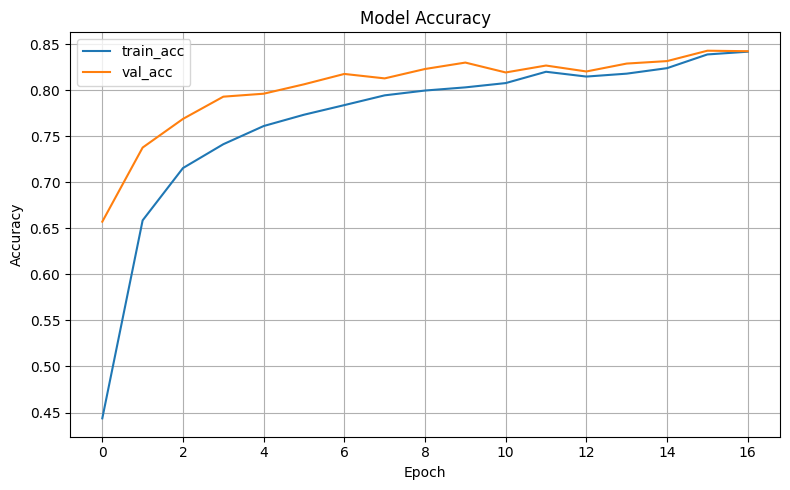

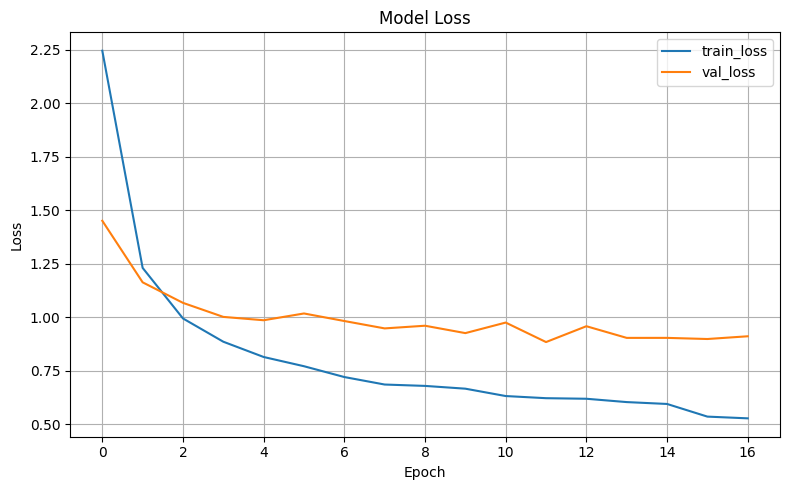

In [48]:
os.makedirs("trainingplots_2", exist_ok=True)

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("trainingplots_2/accuracy.png")
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("trainingplots_2/loss.png")
plt.show()


In [51]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

In [53]:
model.save("trained_model_2.h5")

In [54]:
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("trained_model_2.h5")


In [56]:
import pandas as pd
df = pd.read_excel("Itineary.xlsx")

In [57]:
df.columns

Index(['Monuments', 'Description', 'Short Description', 'Location', 'Region',
       'Country', 'Year Built', 'Visiting Hours', 'Ticket Price',
       'Historical Context', 'Fun Facts', 'Rating', 'Review Count'],
      dtype='object')

In [58]:
def normalize(name):
    return name.lower().replace("_", " ").strip()

df['norm'] = df['Monuments'].apply(normalize)

In [59]:
itinerary_map = {
    row['norm']: row for _, row in df.iterrows()
}

In [60]:
from PIL import Image
import numpy as np

def predict_monument_with_itinerary(image_path):
    
    image = Image.open(image_path).convert("RGB")
    
    image = image.resize((224, 224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    
    preds = model.predict(image)
    pred_index = np.argmax(preds)
    predicted_class = class_names[pred_index]
    
    predicted_norm = normalize(predicted_class)
    
    itinerary = itinerary_map.get(predicted_norm)
    
    if itinerary is not None:
        return {
            "monument": predicted_class,
            "location": itinerary['Location'],
            "rating": itinerary['Rating'],
            "region": itinerary['Region'],
            "country": itinerary['Country'],
            "year_built": itinerary['Year Built'],
            "visiting_hours": itinerary['Visiting Hours'],
            "ticket_price": itinerary['Ticket Price'],
            "description": itinerary['Description'],
            "fun_facts": itinerary['Fun Facts'],
            "historical_context": itinerary['Historical Context'],
            "review_count": itinerary['Review Count'],
        }
    
    return {
        "monument": predicted_class,
        "itinerary": None,
    }

In [61]:
predict_monument_with_itinerary(
    "Dataset/Test/Statue of Liberty/9ad70d3d63.jpg"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step


{'monument': 'Statue of Liberty',
 'location': '📍 View on Google Maps',
 'rating': 4.7,
 'region': 'North America',
 'country': 'USA',
 'year_built': '1886',
 'visiting_hours': '9:00 AM - 5:00 PM',
 'ticket_price': 'USD 24.50 (adults, includes ferry)',
 'description': 'The Statue of Liberty is a colossal neoclassical sculpture on Liberty Island in New York Harbor in New York City. A gift from France to the United States, it was designed by French sculptor Frédéric Auguste Bartholdi and dedicated on October 28, 1886.',
 'fun_facts': 'The statue is 93 metres tall including its pedestal.\nHer crown has 7 spikes representing the seven seas and continents.\nOver 4 million people visit every year.',
 'historical_context': 'The statue was a gift from France to the United States as a symbol of shared values of freedom and democracy. It was designated a UNESCO World Heritage Site in 1984 and has welcomed millions of immigrants arriving by sea.',
 'review_count': 142000}